In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from datetime import datetime
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_with_selected_features_and_all_outliers = pd.read_csv("../data/data_cleaned_selected_with_all_outliers.csv", index_col=0)
df_with_selected_features_and_no_outliers = pd.read_csv("../data/data_cleaned_selected_with_no_outliers.csv", index_col=0)
df_with_all_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_all_outliers_and_all_features.csv", index_col=0)
df_with_no_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_no_outliers_and_all_features.csv", index_col=0)
print("Data Shape of df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.shape)
print("Data Shape of df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.shape)
print("Data Shape of df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.shape)
print("Data Shape of df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.shape)

Data Shape of df_with_selected_features_and_all_outliers:  (4424, 6)
Data Shape of df_with_selected_features_and_no_outliers:  (4335, 6)
Data Shape of df_with_all_outliers_and_all_features:  (4424, 35)
Data Shape of df_with_no_outliers_and_all_features:  (4335, 35)


In [3]:
print("Columns in df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.columns)
print("Columns in df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.columns)

Columns in df_with_selected_features_and_all_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')
Columns in df_with_selected_features_and_no_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')


In [4]:
print("Columns in df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.columns)
print("Columns in df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.columns)

Columns in df_with_all_outliers_and_all_features:  Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
   

In [5]:
X_a_o_a_f = df_with_all_outliers_and_all_features.drop("Target", axis=1)
y_a_o_a_f = df_with_all_outliers_and_all_features["Target"]
X_a_o_s_f = df_with_selected_features_and_all_outliers.drop("Target", axis=1)
y_a_o_s_f = df_with_selected_features_and_all_outliers["Target"]
X_n_o_a_f = df_with_no_outliers_and_all_features.drop("Target", axis=1)
y_n_o_a_f = df_with_no_outliers_and_all_features["Target"]
X_n_o_s_f = df_with_selected_features_and_no_outliers.drop("Target", axis=1)
y_n_o_s_f = df_with_selected_features_and_no_outliers["Target"]

X_train_a_o_a_f, X_test_a_o_a_f, y_train_a_o_a_f, y_test_a_o_a_f = train_test_split(
    X_a_o_a_f, y_a_o_a_f, test_size=0.2, random_state=42, stratify=y_a_o_a_f
)
X_train_a_o_s_f, X_test_a_o_s_f, y_train_a_o_s_f, y_test_a_o_s_f = train_test_split(
    X_a_o_s_f, y_a_o_s_f, test_size=0.2, random_state=42, stratify=y_a_o_s_f
)
X_train_n_o_a_f, X_test_n_o_a_f, y_train_n_o_a_f, y_test_n_o_a_f = train_test_split(
    X_n_o_a_f, y_n_o_a_f, test_size=0.2, random_state=42, stratify=y_n_o_a_f
)
X_train_n_o_s_f, X_test_n_o_s_f, y_train_n_o_s_f, y_test_n_o_s_f = train_test_split(
    X_n_o_s_f, y_n_o_s_f, test_size=0.2, random_state=42, stratify=y_n_o_s_f
)

# **Desicion Tree Classifier without Hyperparameter Tuning**

In [6]:
dt_a_o_a_f = DecisionTreeClassifier(random_state=42)
dt_a_o_a_f.fit(X_train_a_o_a_f, y_train_a_o_a_f)
dt_a_o_s_f = DecisionTreeClassifier(random_state=42)
dt_a_o_s_f.fit(X_train_a_o_s_f, y_train_a_o_s_f)
dt_n_o_a_f = DecisionTreeClassifier(random_state=42)
dt_n_o_a_f.fit(X_train_n_o_a_f, y_train_n_o_a_f)
dt_n_o_s_f = DecisionTreeClassifier(random_state=42)
dt_n_o_s_f.fit(X_train_n_o_s_f, y_train_n_o_s_f)

dt_a_o_a_f_pred = dt_a_o_a_f.predict(X_test_a_o_a_f)
dt_a_o_s_f_pred = dt_a_o_s_f.predict(X_test_a_o_s_f)
dt_n_o_a_f_pred = dt_n_o_a_f.predict(X_test_n_o_a_f)
dt_n_o_s_f_pred = dt_n_o_s_f.predict(X_test_n_o_s_f)

# Classification Report
print("Classification Report - Decision Tree Classifier with All Outliers and All Features:")
print(classification_report(y_test_a_o_a_f, dt_a_o_a_f_pred))
print("Classification Report - Decision Tree Classifier with All Outliers and Selected Features:")
print(classification_report(y_test_a_o_s_f, dt_a_o_s_f_pred))

Classification Report - Decision Tree Classifier with All Outliers and All Features:
              precision    recall  f1-score   support

           0       0.70      0.67      0.68       284
           1       0.38      0.42      0.40       159
           2       0.80      0.79      0.79       442

    accuracy                           0.68       885
   macro avg       0.63      0.63      0.63       885
weighted avg       0.69      0.68      0.69       885

Classification Report - Decision Tree Classifier with All Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       284
           1       0.36      0.31      0.33       159
           2       0.80      0.78      0.79       442

    accuracy                           0.69       885
   macro avg       0.62      0.62      0.62       885
weighted avg       0.69      0.69      0.69       885



In [7]:
print("Classification Report - Decision Tree Classifier with No Outliers and All Features:")
print(classification_report(y_test_n_o_a_f, dt_n_o_a_f_pred))
print("Classification Report - Decision Tree Classifier with No Outliers and Selected Features:")
print(classification_report(y_test_n_o_s_f, dt_n_o_s_f_pred))

Classification Report - Decision Tree Classifier with No Outliers and All Features:
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       279
           1       0.38      0.37      0.38       155
           2       0.79      0.79      0.79       433

    accuracy                           0.68       867
   macro avg       0.62      0.62      0.62       867
weighted avg       0.68      0.68      0.68       867

Classification Report - Decision Tree Classifier with No Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       279
           1       0.38      0.32      0.35       155
           2       0.76      0.81      0.78       433

    accuracy                           0.69       867
   macro avg       0.62      0.61      0.61       867
weighted avg       0.68      0.69      0.68       867



Confusion Matrix - Decision Tree Classifier with All Outliers and All Features:


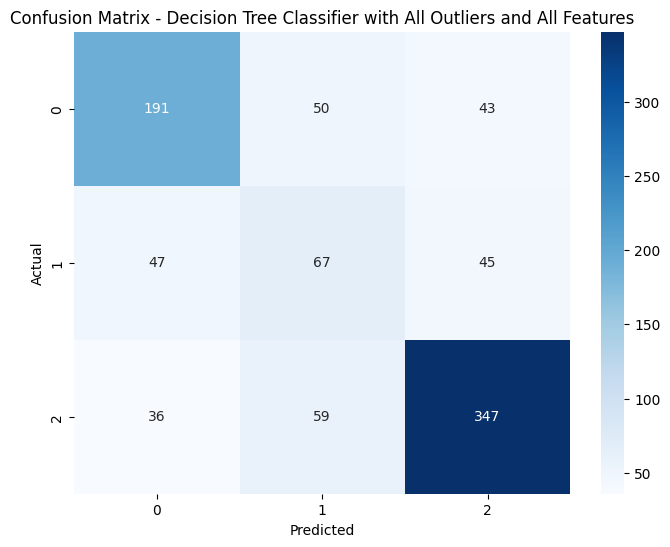

Confusion Matrix - Decision Tree Classifier with All Outliers and Selected Features:


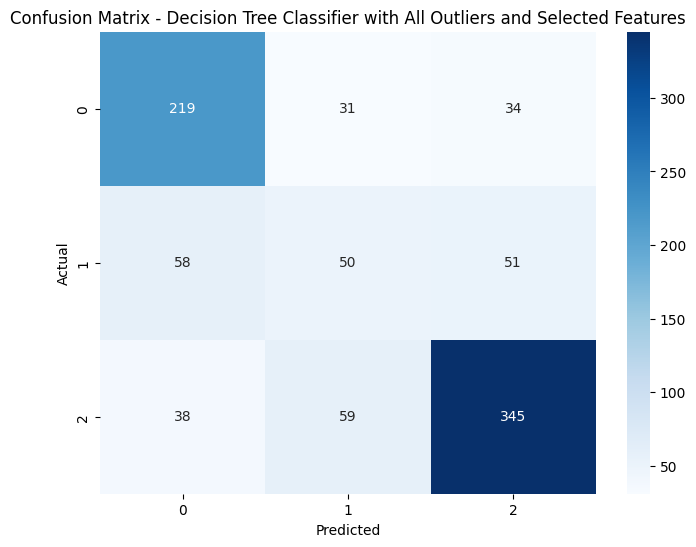

Confusion Matrix - Decision Tree Classifier with No Outliers and All Features:


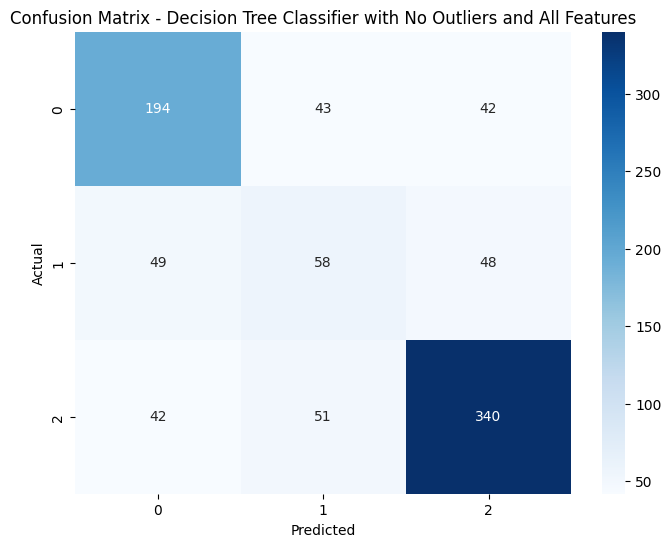

Confusion Matrix - Decision Tree Classifier with No Outliers and Selected Features:


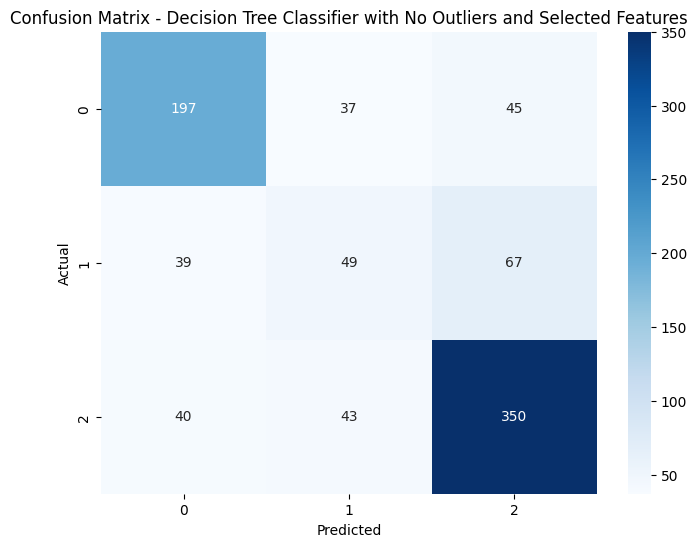

In [8]:
# Plot Confusion Matrix Chart
print("Confusion Matrix - Decision Tree Classifier with All Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_a_f, dt_a_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Classifier with All Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Decision Tree Classifier with All Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_s_f, dt_a_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Classifier with All Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Decision Tree Classifier with No Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_a_f, dt_n_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Classifier with No Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Decision Tree Classifier with No Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_s_f, dt_n_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Classifier with No Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# Accuracy Score
print("Accuracy Score - Decision Tree Classifier with All Outliers and All Features:", accuracy_score(y_test_a_o_a_f, dt_a_o_a_f_pred))
print("Accuracy Score - Decision Tree Classifier with All Outliers and Selected Features:", accuracy_score(y_test_a_o_s_f, dt_a_o_s_f_pred))
print("Accuracy Score - Decision Tree Classifier with No Outliers and All Features:", accuracy_score(y_test_n_o_a_f, dt_n_o_a_f_pred))
print("Accuracy Score - Decision Tree Classifier with No Outliers and Selected Features:", accuracy_score(y_test_n_o_s_f, dt_n_o_s_f_pred))

Accuracy Score - Decision Tree Classifier with All Outliers and All Features: 0.6836158192090396
Accuracy Score - Decision Tree Classifier with All Outliers and Selected Features: 0.6937853107344633
Accuracy Score - Decision Tree Classifier with No Outliers and All Features: 0.6828143021914648
Accuracy Score - Decision Tree Classifier with No Outliers and Selected Features: 0.6874279123414071


In [10]:
# ROC AUC Score
print("ROC AUC Score - Decision Tree Classifier with All Outliers and All Features:", roc_auc_score(y_test_a_o_a_f, dt_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Decision Tree Classifier with All Outliers and Selected Features:", roc_auc_score(y_test_a_o_s_f, dt_a_o_s_f.predict_proba(X_test_a_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Decision Tree Classifier with No Outliers and All Features:", roc_auc_score(y_test_n_o_a_f, dt_n_o_a_f.predict_proba(X_test_n_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Decision Tree Classifier with No Outliers and Selected Features:", roc_auc_score(y_test_n_o_s_f, dt_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'))

ROC AUC Score - Decision Tree Classifier with All Outliers and All Features: 0.7320167052884803
ROC AUC Score - Decision Tree Classifier with All Outliers and Selected Features: 0.7721316987493436
ROC AUC Score - Decision Tree Classifier with No Outliers and All Features: 0.7267659668593168
ROC AUC Score - Decision Tree Classifier with No Outliers and Selected Features: 0.7614806206476601


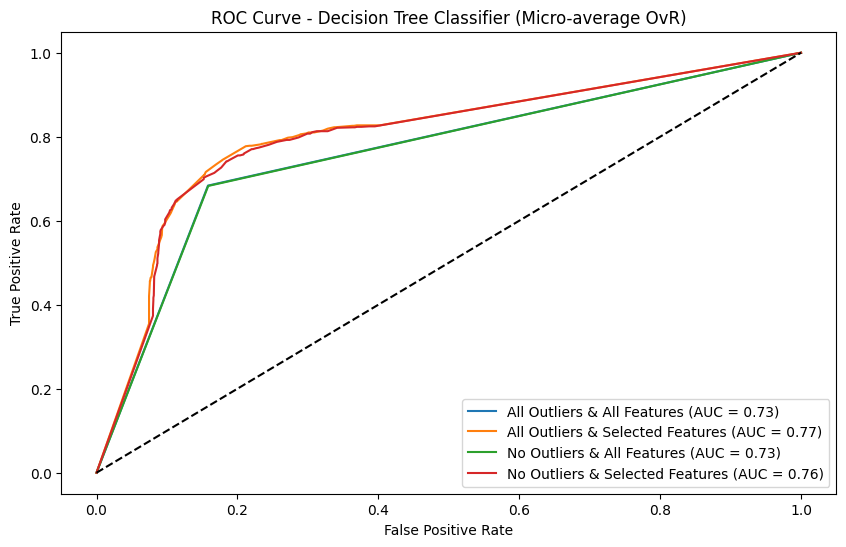

In [11]:
# ROC Curve (multiclass-safe, micro-average)
def get_micro_roc(y_true, y_proba, class_labels):
    y_true_bin = label_binarize(y_true, classes=class_labels)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr')
    return fpr, tpr, auc_score

fpr_a_o_a_f, tpr_a_o_a_f, auc_a_o_a_f = get_micro_roc(
    y_test_a_o_a_f, dt_a_o_a_f.predict_proba(X_test_a_o_a_f), dt_a_o_a_f.classes_
)
fpr_a_o_s_f, tpr_a_o_s_f, auc_a_o_s_f = get_micro_roc(
    y_test_a_o_s_f, dt_a_o_s_f.predict_proba(X_test_a_o_s_f), dt_a_o_s_f.classes_
)
fpr_n_o_a_f, tpr_n_o_a_f, auc_n_o_a_f = get_micro_roc(
    y_test_n_o_a_f, dt_n_o_a_f.predict_proba(X_test_n_o_a_f), dt_n_o_a_f.classes_
)
fpr_n_o_s_f, tpr_n_o_s_f, auc_n_o_s_f = get_micro_roc(
    y_test_n_o_s_f, dt_n_o_s_f.predict_proba(X_test_n_o_s_f), dt_n_o_s_f.classes_
)

plt.figure(figsize=(10, 6))
plt.plot(fpr_a_o_a_f, tpr_a_o_a_f, label='All Outliers & All Features (AUC = {:.2f})'.format(auc_a_o_a_f))
plt.plot(fpr_a_o_s_f, tpr_a_o_s_f, label='All Outliers & Selected Features (AUC = {:.2f})'.format(auc_a_o_s_f))
plt.plot(fpr_n_o_a_f, tpr_n_o_a_f, label='No Outliers & All Features (AUC = {:.2f})'.format(auc_n_o_a_f))
plt.plot(fpr_n_o_s_f, tpr_n_o_s_f, label='No Outliers & Selected Features (AUC = {:.2f})'.format(auc_n_o_s_f))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree Classifier (Micro-average OvR)')
plt.legend(loc='lower right')
plt.show()

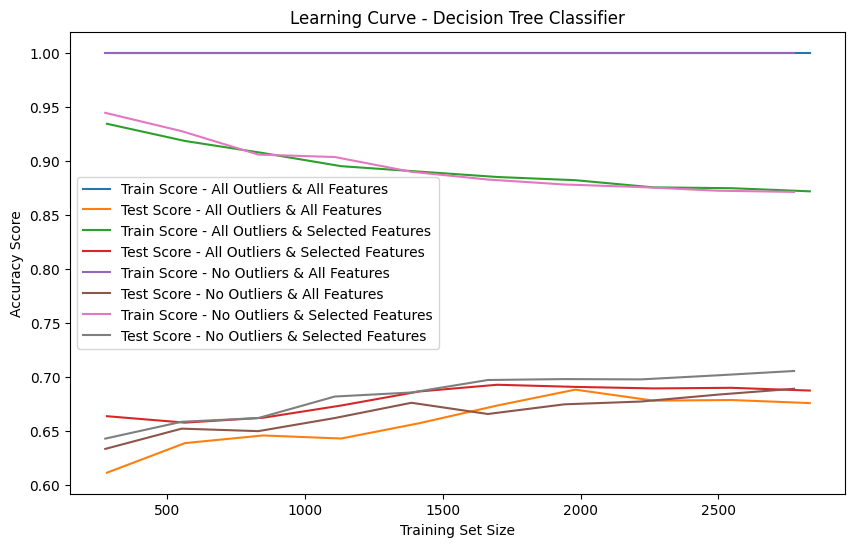

In [12]:
# Learning Curve
train_sizes_a_o_a_f, train_scores_a_o_a_f, test_scores_a_o_a_f = learning_curve(
    dt_a_o_a_f, X_train_a_o_a_f, y_train_a_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_a_o_s_f, train_scores_a_o_s_f, test_scores_a_o_s_f = learning_curve(
    dt_a_o_s_f, X_train_a_o_s_f, y_train_a_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_a_f, train_scores_n_o_a_f, test_scores_n_o_a_f = learning_curve(
    dt_n_o_a_f, X_train_n_o_a_f, y_train_n_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_s_f, train_scores_n_o_s_f, test_scores_n_o_s_f = learning_curve(
    dt_n_o_s_f, X_train_n_o_s_f, y_train_n_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_a_o_a_f, np.mean(train_scores_a_o_a_f, axis=1), label='Train Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_a_f, np.mean(test_scores_a_o_a_f, axis=1), label='Test Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_s_f, np.mean(train_scores_a_o_s_f, axis=1), label='Train Score - All Outliers & Selected Features')
plt.plot(train_sizes_a_o_s_f, np.mean(test_scores_a_o_s_f, axis=1), label='Test Score - All Outliers & Selected Features')
plt.plot(train_sizes_n_o_a_f, np.mean(train_scores_n_o_a_f, axis=1), label='Train Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_a_f, np.mean(test_scores_n_o_a_f, axis=1), label='Test Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_s_f, np.mean(train_scores_n_o_s_f, axis=1), label='Train Score - No Outliers & Selected Features')
plt.plot(train_sizes_n_o_s_f, np.mean(test_scores_n_o_s_f, axis=1), label='Test Score - No Outliers & Selected Features')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curve - Decision Tree Classifier')
plt.legend(loc='best')
plt.show()

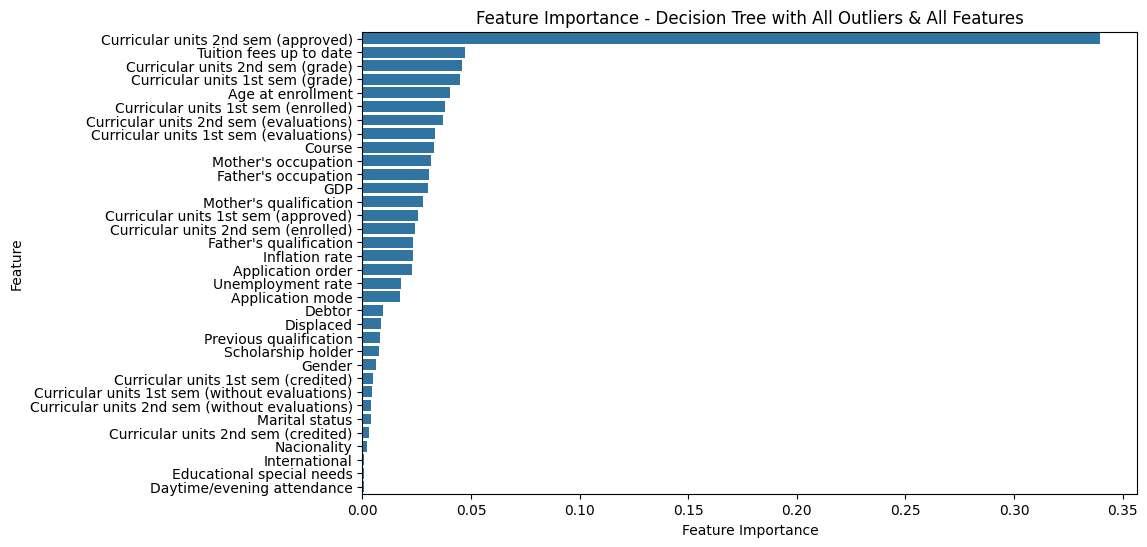

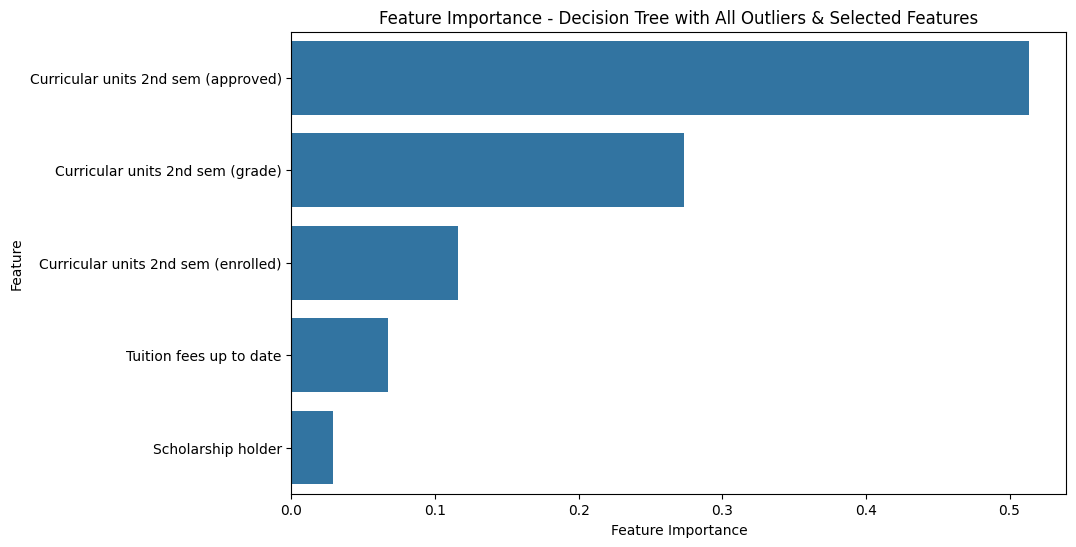

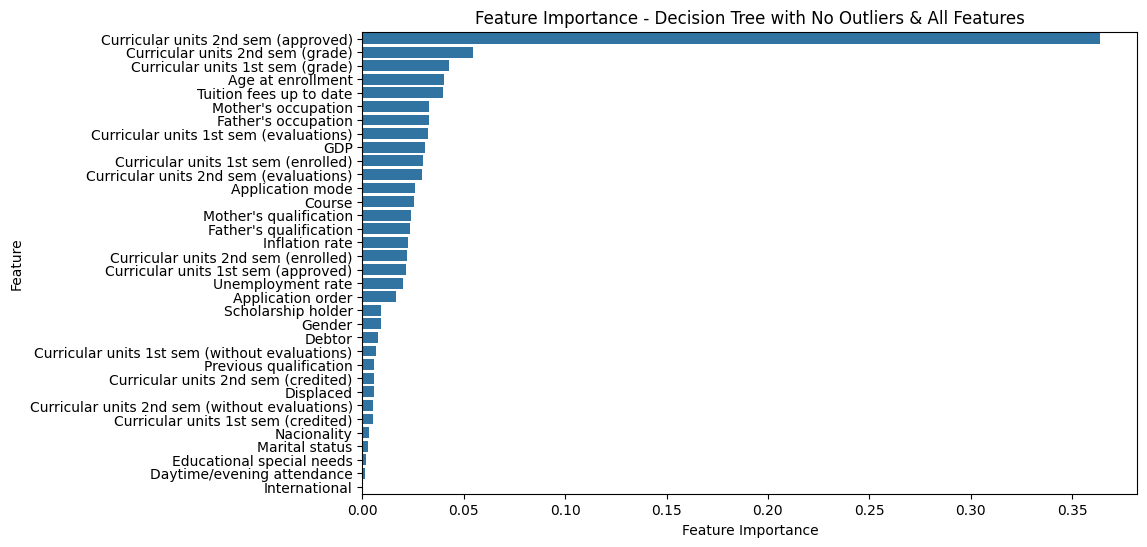

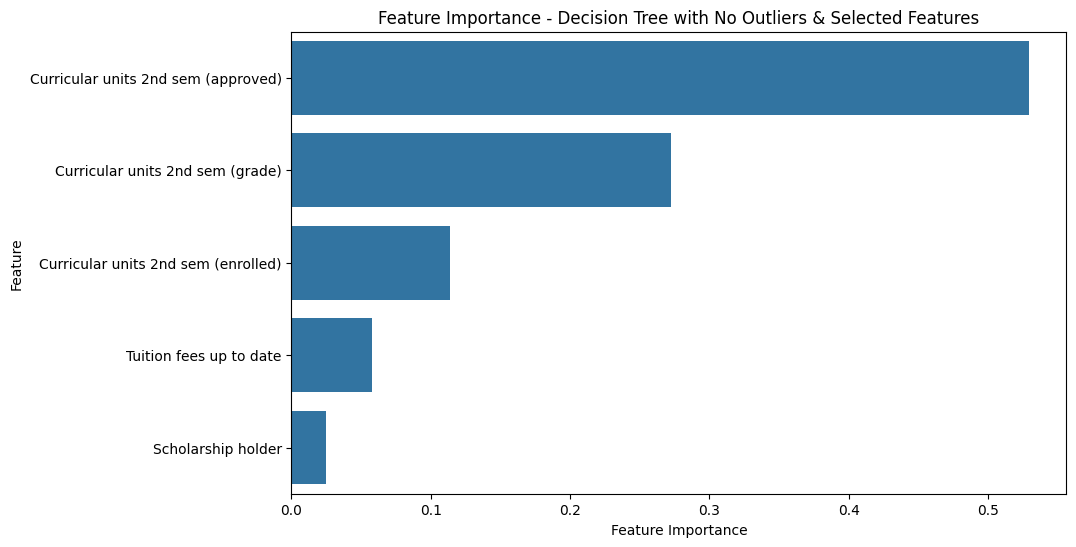

In [13]:
def plot_feature_importance(model, feature_names, title):
    importance = model.feature_importances_
    indices = np.argsort(importance)[::-1]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance[indices], y=np.array(feature_names)[indices])
    plt.title(title)
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.show()
plot_feature_importance(dt_a_o_a_f, X_train_a_o_a_f.columns, "Feature Importance - Decision Tree with All Outliers & All Features")
plot_feature_importance(dt_a_o_s_f, X_train_a_o_s_f.columns, "Feature Importance - Decision Tree with All Outliers & Selected Features")
plot_feature_importance(dt_n_o_a_f, X_train_n_o_a_f.columns, "Feature Importance - Decision Tree with No Outliers & All Features")
plot_feature_importance(dt_n_o_s_f, X_train_n_o_s_f.columns, "Feature Importance - Decision Tree with No Outliers & Selected Features")

## **Model Evaluation Summary (Updated from Latest Rerun)**

The strongest tuned configuration by test metrics in this notebook is:
**Decision Tree with All Outliers and Selected Features**

### Key Metrics (Tuned Models)
- **Best Accuracy**: 0.7367 (All Outliers + Selected Features)
- **Best ROC-AUC**: 0.8488 (All Outliers + Selected Features)
- **5-Fold CV cell (currently configured on NO+SF)**: mean 0.7388, std 0.0135

### Interpretation
- In the latest rerun, selected-feature variants outperform all-feature variants for Decision Tree.
- For this model family, retaining outliers with selected features produced the best test-set quality.
- Decision Tree still shows generalization limits (especially class Enrolled), so use as simpler baseline/interpretable model.

### Conclusion
Primary candidate from this notebook: **Tuned Decision Tree (All Outliers + Selected Features)**.

# **Decision Tree with Hyperparameter Tuning**

## **Coarse-to-Fine-Search**

### **RandomSearchCV**

In [ ]:
# param_dist_dt = {
#     'max_depth'         : [None] + list(np.arange(5, 51, 5)),
#     'min_samples_split' : np.arange(2, 21),
#     'min_samples_leaf'  : np.arange(1, 11),
#     'max_features'      : ['sqrt', 'log2', None, 0.3, 0.5, 0.7],
#     'criterion'         : ['gini', 'entropy'],
#     'splitter'          : ['best', 'random'],
#     'class_weight'      : [None, 'balanced']
# }

# random_search_dt1 = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_distributions=param_dist_dt, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_dt1.fit(X_train_a_o_s_f, y_train_a_o_s_f)
# print("Best Hyperparameters for Decision Tree Classifier with All Outliers and Selected Features (Randomized Search):")
# print(random_search_dt1.best_params_)

# random_search_dt2 = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_distributions=param_dist_dt, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_dt2.fit(X_train_n_o_s_f, y_train_n_o_s_f)
# print("Best Hyperparameters for Decision Tree Classifier with No Outliers and Selected Features (Randomized Search):")
# print(random_search_dt2.best_params_)

# random_search_dt3 = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_distributions=param_dist_dt, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_dt3.fit(X_train_a_o_a_f, y_train_a_o_a_f)
# print("Best Hyperparameters for Decision Tree Classifier with All Outliers and All Features (Randomized Search):")
# print(random_search_dt3.best_params_)

# random_search_dt4 = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_distributions=param_dist_dt, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_dt4.fit(X_train_n_o_a_f, y_train_n_o_a_f)
# print("Best Hyperparameters for Decision Tree Classifier with No Outliers and All Features (Randomized Search):")
# print(random_search_dt4.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for Decision Tree Classifier with All Outliers and Selected Features (Randomized Search):
{'splitter': 'random', 'min_samples_split': np.int64(16), 'min_samples_leaf': np.int64(10), 'max_features': 'log2', 'max_depth': np.int64(10), 'criterion': 'gini', 'class_weight': None}
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for Decision Tree Classifier with No Outliers and Selected Features (Randomized Search):
{'splitter': 'random', 'min_samples_split': np.int64(18), 'min_samples_leaf': np.int64(9), 'max_features': None, 'max_depth': np.int64(50), 'criterion': 'gini', 'class_weight': None}
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for Decision Tree Classifier with All Outliers and All Features (Randomized Search):
{'splitter': 'best', 'min_samples_split': np.int64(9), 'min_samples_leaf': np.int64(3), 'max_features': 0.5, 'max_d

the duration of RandomSearchCV Task is 9+ Seconds

### **GridSearchCV**

In [ ]:
# param_grid_dt1 = {
#     'max_depth'         : [3, 5, 7],               # sekitar hasil RS
#     'min_samples_split' : [2, 3, 4],               # sekitar hasil RS
#     'min_samples_leaf'  : [1, 2, 3],               # sekitar hasil RS
#     'max_features'      : ['sqrt', 0.3, 0.5],      # sekitar hasil RS
#     'criterion'         : ['gini', 'entropy'],      # sudah pasti dari RS
#     'splitter'          : ['best'],                 # sudah pasti dari RS
#     'class_weight'      : [None, 'balanced']        # sudah pasti dari RS
# }

# grid_dt1 = GridSearchCV(
#     DecisionTreeClassifier(random_state=42),
#     param_grid_dt1, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_dt1.fit(X_train_a_o_s_f, y_train_a_o_s_f)
# print("Best Params DT1:", grid_dt1.best_params_)
# print("Best Score  DT1:", grid_dt1.best_score_)

# param_grid_dt2 = {
#     'max_depth'         : [3, 5, 7],               # sekitar hasil RS
#     'min_samples_split' : [2, 3, 4],               # sekitar hasil RS
#     'min_samples_leaf'  : [1, 2, 3],               # sekitar hasil RS
#     'max_features'      : ['sqrt', 0.3, 0.5],      # sekitar hasil RS
#     'criterion'         : ['gini', 'entropy'],      # sudah pasti dari RS
#     'splitter'          : ['best'],                 # sudah pasti dari RS
#     'class_weight'      : [None, 'balanced']        # sudah pasti dari RS
# }

# grid_dt2 = GridSearchCV(
#     DecisionTreeClassifier(random_state=42),
#     param_grid_dt2, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_dt2.fit(X_train_n_o_s_f, y_train_n_o_s_f)
# print("Best Params DT2:", grid_dt2.best_params_)
# print("Best Score  DT2:", grid_dt2.best_score_)

# param_grid_dt3 = {
#     'max_depth'         : [8, 10, 12],             # sekitar hasil RS
#     'min_samples_split' : [2, 3, 4],               # sekitar hasil RS
#     'min_samples_leaf'  : [1, 2, 3],               # sekitar hasil RS
#     'max_features'      : ['sqrt', 'log2', 0.3],   # sekitar hasil RS
#     'criterion'         : ['gini', 'entropy'],      # sudah pasti dari RS
#     'splitter'          : ['best'],                 # sudah pasti dari RS
#     'class_weight'      : [None, 'balanced']        # sudah pasti dari RS
# }

# grid_dt3 = GridSearchCV(
#     DecisionTreeClassifier(random_state=42),
#     param_grid_dt3, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_dt3.fit(X_train_a_o_a_f, y_train_a_o_a_f)
# print("Best Params DT3:", grid_dt3.best_params_)
# print("Best Score  DT3:", grid_dt3.best_score_)

# param_grid_dt4 = {
#     'max_depth'         : [8, 10, 12],             # sekitar hasil RS
#     'min_samples_split' : [2, 3, 4],               # sekitar hasil RS
#     'min_samples_leaf'  : [1, 2, 3],               # sekitar hasil RS
#     'max_features'      : ['sqrt', 'log2', 0.3],   # sekitar hasil RS
#     'criterion'         : ['gini', 'entropy'],      # sudah pasti dari RS
#     'splitter'          : ['best'],                 # sudah pasti dari RS
#     'class_weight'      : [None, 'balanced']        # sudah pasti dari RS
# }

# grid_dt4 = GridSearchCV(
#     DecisionTreeClassifier(random_state=42),
#     param_grid_dt4, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_dt4.fit(X_train_n_o_a_f, y_train_n_o_a_f)
# print("Best Params DT4:", grid_dt4.best_params_)
# print("Best Score  DT4:", grid_dt4.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Params DT1: {'class_weight': None, 'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'splitter': 'best'}
Best Score  DT1: 0.7400430721038205
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Params DT2: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 3, 'splitter': 'best'}
Best Score  DT2: 0.7413455260717507
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Params DT3: {'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'max_features': 0.3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'splitter': 'best'}
Best Score  DT3: 0.7332642101982596
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Params DT4: {'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'max_features': 0.3, 'min_samples_leaf': 3, 'min_samples_s

## **IMPLEMENTATION TO THE MODELS WITH THE RESULTS OF** ***Coarse-to-Fine-Search***

In [14]:
dt_tuned_a_o_s_f = DecisionTreeClassifier(
    class_weight=None, criterion='gini', max_depth=7, max_features='sqrt',
    min_samples_leaf=1, min_samples_split=4, splitter='best',
    random_state=42
)
dt_tuned_a_o_s_f.fit(X_train_a_o_s_f, y_train_a_o_s_f)

dt_tuned_n_o_s_f = DecisionTreeClassifier(
    class_weight=None, criterion='entropy', max_depth=7, max_features=0.3,
    min_samples_leaf=1, min_samples_split=3, splitter='best',
    random_state=42
)
dt_tuned_n_o_s_f.fit(X_train_n_o_s_f, y_train_n_o_s_f)

dt_tuned_a_o_a_f = DecisionTreeClassifier(
    class_weight=None, criterion='gini', max_depth=8, max_features=0.3,
    min_samples_leaf=3, min_samples_split=2, splitter='best',
    random_state=42
)
dt_tuned_a_o_a_f.fit(X_train_a_o_a_f, y_train_a_o_a_f)

dt_tuned_n_o_a_f = DecisionTreeClassifier(
    class_weight=None, criterion='gini', max_depth=8, max_features=0.3,
    min_samples_leaf=3, min_samples_split=2, splitter='best',
    random_state=42
)
dt_tuned_n_o_a_f.fit(X_train_n_o_a_f, y_train_n_o_a_f)

dt_tuned_a_o_s_f_pred = dt_tuned_a_o_s_f.predict(X_test_a_o_s_f)
dt_tuned_n_o_s_f_pred = dt_tuned_n_o_s_f.predict(X_test_n_o_s_f)
dt_tuned_a_o_a_f_pred = dt_tuned_a_o_a_f.predict(X_test_a_o_a_f)
dt_tuned_n_o_a_f_pred = dt_tuned_n_o_a_f.predict(X_test_n_o_a_f)

In [15]:
from sklearn.model_selection import cross_val_score

cv_scores_dt_best = cross_val_score(
    dt_tuned_n_o_s_f,
    X_train_n_o_s_f,
    y_train_n_o_s_f,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross Validation Score (5-Fold) - Tuned Decision Tree (No Outliers + Selected Features):")
print("CV Scores:", np.round(cv_scores_dt_best, 4))
print("Mean CV Accuracy:", round(cv_scores_dt_best.mean(), 4))
print("Std CV Accuracy :", round(cv_scores_dt_best.std(), 4))

Cross Validation Score (5-Fold) - Tuned Decision Tree (No Outliers + Selected Features):
CV Scores: [0.755  0.7147 0.7464 0.7403 0.7374]
Mean CV Accuracy: 0.7388
Std CV Accuracy : 0.0135


In [16]:
# Classification Report after Hyperparameter Tuning with Coarse-to-Fine Search
print("Classification Report - Tuned Decision Tree Classifier with All Outliers and Selected Features:")
print(classification_report(y_test_a_o_s_f, dt_tuned_a_o_s_f_pred))
print("Classification Report - Tuned Decision Tree Classifier with No Outliers and Selected Features:")
print(classification_report(y_test_n_o_s_f, dt_tuned_n_o_s_f_pred))

Classification Report - Tuned Decision Tree Classifier with All Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75       284
           1       0.43      0.31      0.36       159
           2       0.79      0.89      0.84       442

    accuracy                           0.74       885
   macro avg       0.66      0.65      0.65       885
weighted avg       0.72      0.74      0.72       885

Classification Report - Tuned Decision Tree Classifier with No Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.77      0.68      0.73       279
           1       0.34      0.27      0.30       155
           2       0.76      0.88      0.82       433

    accuracy                           0.71       867
   macro avg       0.63      0.61      0.62       867
weighted avg       0.69      0.71      0.70       867



In [17]:
print("Classification Report - Tuned Decision Tree Classifier with All Outliers and All Features:")
print(classification_report(y_test_a_o_a_f, dt_tuned_a_o_a_f_pred))
print("Classification Report - Tuned Decision Tree Classifier with No Outliers and All Features:")
print(classification_report(y_test_n_o_a_f, dt_tuned_n_o_a_f_pred))

Classification Report - Tuned Decision Tree Classifier with All Outliers and All Features:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70       284
           1       0.42      0.33      0.37       159
           2       0.78      0.88      0.83       442

    accuracy                           0.72       885
   macro avg       0.65      0.63      0.64       885
weighted avg       0.70      0.72      0.71       885

Classification Report - Tuned Decision Tree Classifier with No Outliers and All Features:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73       279
           1       0.38      0.34      0.36       155
           2       0.77      0.84      0.80       433

    accuracy                           0.70       867
   macro avg       0.64      0.63      0.63       867
weighted avg       0.70      0.70      0.70       867



Confusion Matrix - Tuned Decision Tree Classifier with All Outliers and All Features after:


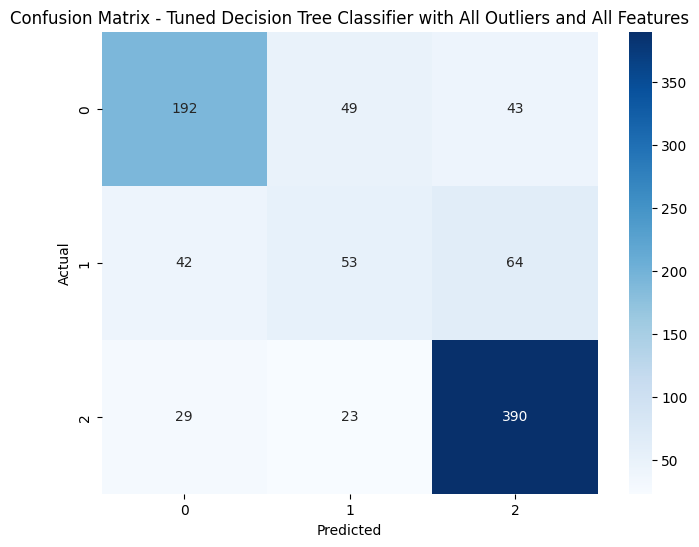

Confusion Matrix - Tuned Decision Tree Classifier with All Outliers and Selected Features:


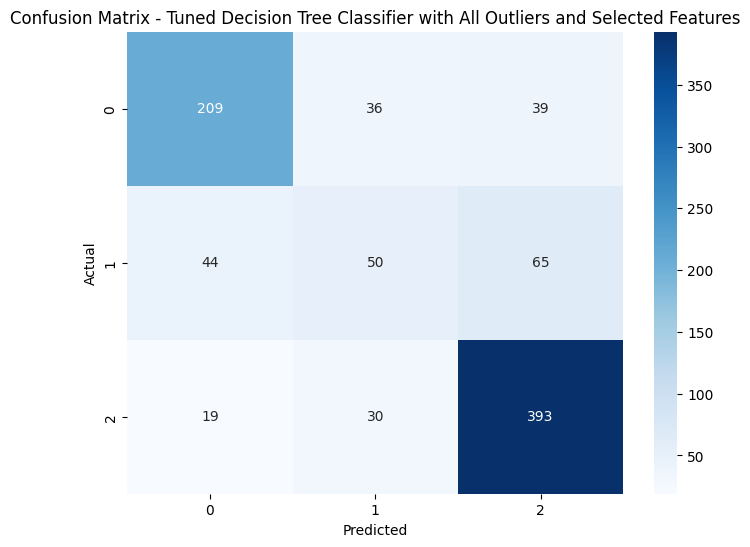

Confusion Matrix - Tuned Decision Tree Classifier with No Outliers and All Features:


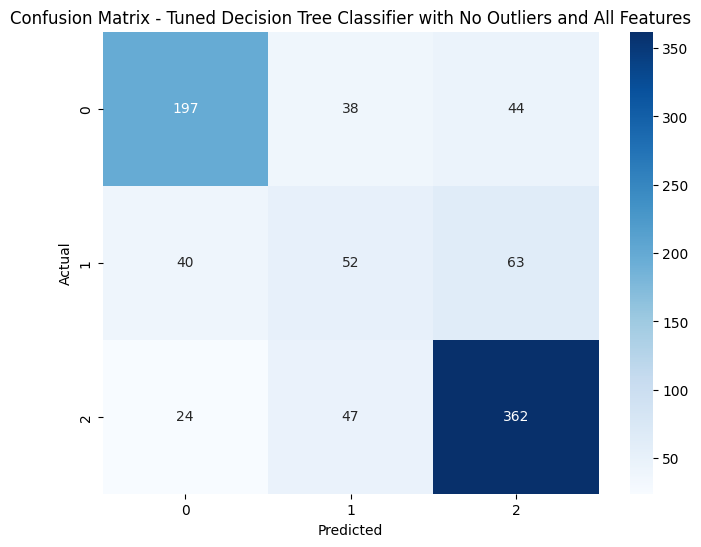

Confusion Matrix - Tuned Decision Tree Classifier with No Outliers and Selected Features:


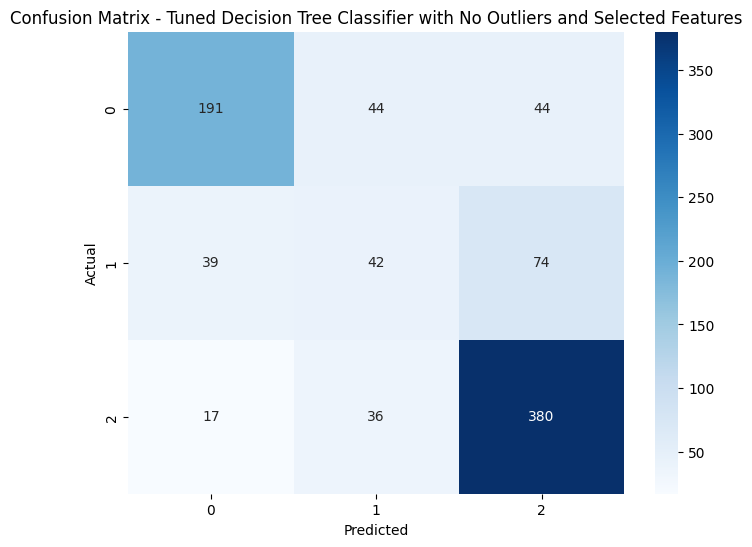

In [18]:
# Plot Confusion Matrix Chart after Hyperparameter Tuning with Coarse-to-Fine Search
print("Confusion Matrix - Tuned Decision Tree Classifier with All Outliers and All Features after:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_a_f, dt_tuned_a_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Decision Tree Classifier with All Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Tuned Decision Tree Classifier with All Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_s_f, dt_tuned_a_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Decision Tree Classifier with All Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Tuned Decision Tree Classifier with No Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_a_f, dt_tuned_n_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Decision Tree Classifier with No Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Tuned Decision Tree Classifier with No Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_s_f, dt_tuned_n_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Decision Tree Classifier with No Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Accuracy Score after Hyperparameter Tuning with Coarse-to-Fine Search
print("Accuracy Score - Tuned Decision Tree Classifier with All Outliers and Selected Features:", accuracy_score(y_test_a_o_s_f, dt_tuned_a_o_s_f_pred))
print("Accuracy Score - Tuned Decision Tree Classifier with No Outliers and Selected Features:", accuracy_score(y_test_n_o_s_f, dt_tuned_n_o_s_f_pred))
print("Accuracy Score - Tuned Decision Tree Classifier with All Outliers and All Features:", accuracy_score(y_test_a_o_a_f, dt_tuned_a_o_a_f_pred))
print("Accuracy Score - Tuned Decision Tree Classifier with No Outliers and All Features:", accuracy_score(y_test_n_o_a_f, dt_tuned_n_o_a_f_pred))

Accuracy Score - Tuned Decision Tree Classifier with All Outliers and Selected Features: 0.7367231638418079
Accuracy Score - Tuned Decision Tree Classifier with No Outliers and Selected Features: 0.707035755478662
Accuracy Score - Tuned Decision Tree Classifier with All Outliers and All Features: 0.7175141242937854
Accuracy Score - Tuned Decision Tree Classifier with No Outliers and All Features: 0.7047289504036909


In [20]:
# Roc AUC Score after Hyperparameter Tuning with Coarse-to-Fine Search
print("ROC AUC Score - Tuned Decision Tree Classifier with All Outliers and Selected Features:", roc_auc_score(y_test_a_o_s_f, dt_tuned_a_o_s_f.predict_proba(X_test_a_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Tuned Decision Tree Classifier with No Outliers and Selected Features:", roc_auc_score(y_test_n_o_s_f, dt_tuned_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Tuned Decision Tree Classifier with All Outliers and All Features:", roc_auc_score(y_test_a_o_a_f, dt_tuned_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Tuned Decision Tree Classifier with No Outliers and All Features:", roc_auc_score(y_test_n_o_a_f, dt_tuned_n_o_a_f.predict_proba(X_test_n_o_a_f), multi_class='ovr'))

ROC AUC Score - Tuned Decision Tree Classifier with All Outliers and Selected Features: 0.8488410078521911
ROC AUC Score - Tuned Decision Tree Classifier with No Outliers and Selected Features: 0.8162505273537494
ROC AUC Score - Tuned Decision Tree Classifier with All Outliers and All Features: 0.8071896089754609
ROC AUC Score - Tuned Decision Tree Classifier with No Outliers and All Features: 0.8033389822414385


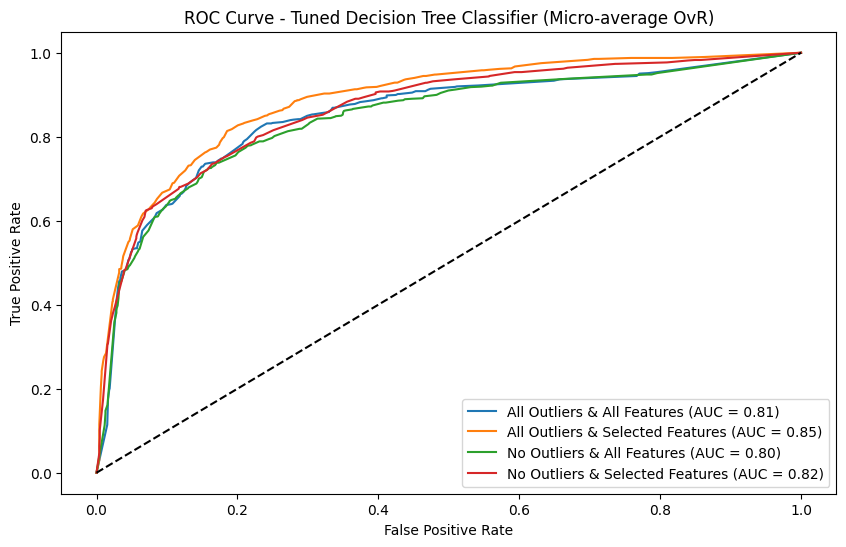

In [21]:
# ROC Curve (multiclass-safe, micro-average)
def get_micro_roc(y_true, y_proba, class_labels):
    y_true_bin = label_binarize(y_true, classes=class_labels)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr')
    return fpr, tpr, auc_score

fpr_a_o_a_f, tpr_a_o_a_f, auc_a_o_a_f = get_micro_roc(
    y_test_a_o_a_f, dt_tuned_a_o_a_f.predict_proba(X_test_a_o_a_f), dt_tuned_a_o_a_f.classes_
)
fpr_a_o_s_f, tpr_a_o_s_f, auc_a_o_s_f = get_micro_roc(
    y_test_a_o_s_f, dt_tuned_a_o_s_f.predict_proba(X_test_a_o_s_f), dt_tuned_a_o_s_f.classes_
)
fpr_n_o_a_f, tpr_n_o_a_f, auc_n_o_a_f = get_micro_roc(
    y_test_n_o_a_f, dt_tuned_n_o_a_f.predict_proba(X_test_n_o_a_f), dt_tuned_n_o_a_f.classes_
)
fpr_n_o_s_f, tpr_n_o_s_f, auc_n_o_s_f = get_micro_roc(
    y_test_n_o_s_f, dt_tuned_n_o_s_f.predict_proba(X_test_n_o_s_f), dt_tuned_n_o_s_f.classes_
)

plt.figure(figsize=(10, 6))
plt.plot(fpr_a_o_a_f, tpr_a_o_a_f, label='All Outliers & All Features (AUC = {:.2f})'.format(auc_a_o_a_f))
plt.plot(fpr_a_o_s_f, tpr_a_o_s_f, label='All Outliers & Selected Features (AUC = {:.2f})'.format(auc_a_o_s_f))
plt.plot(fpr_n_o_a_f, tpr_n_o_a_f, label='No Outliers & All Features (AUC = {:.2f})'.format(auc_n_o_a_f))
plt.plot(fpr_n_o_s_f, tpr_n_o_s_f, label='No Outliers & Selected Features (AUC = {:.2f})'.format(auc_n_o_s_f))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Decision Tree Classifier (Micro-average OvR)')
plt.legend(loc='lower right')
plt.show()

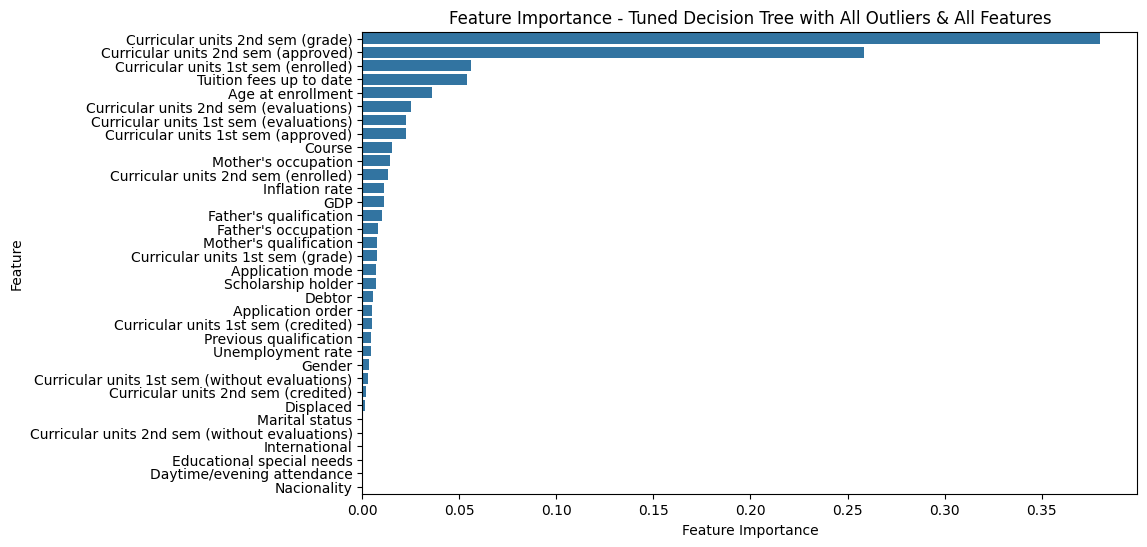

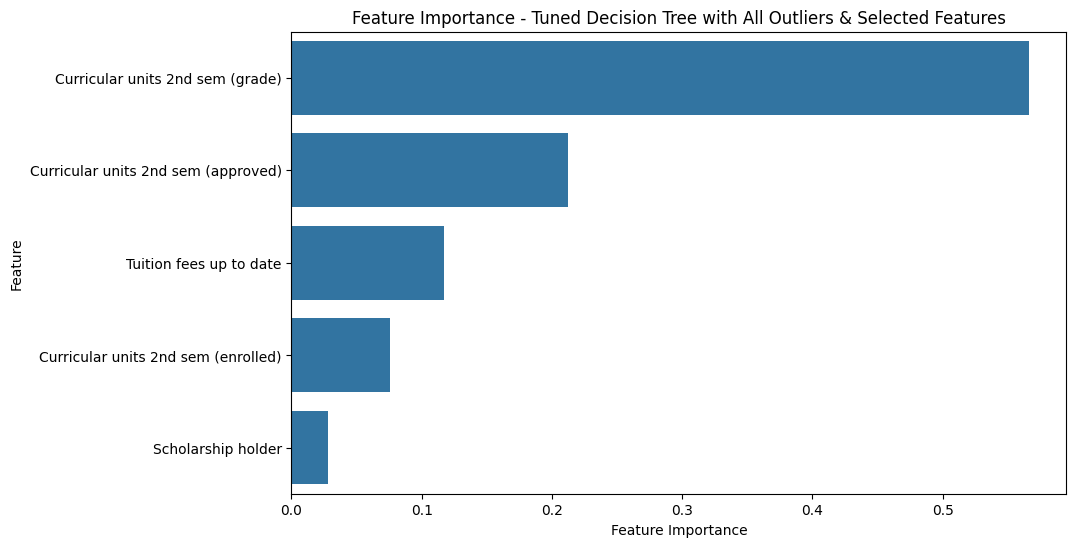

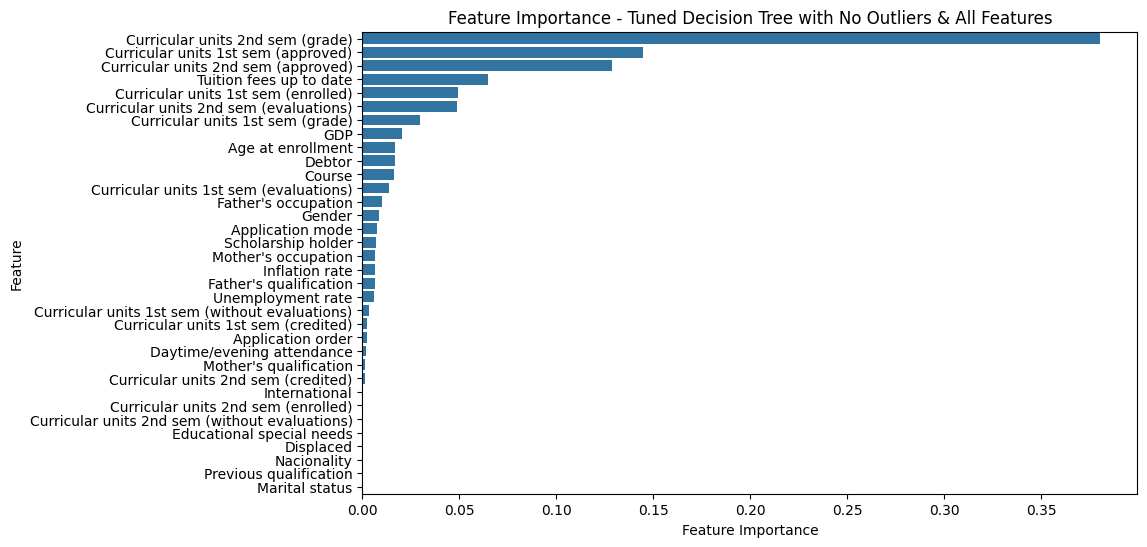

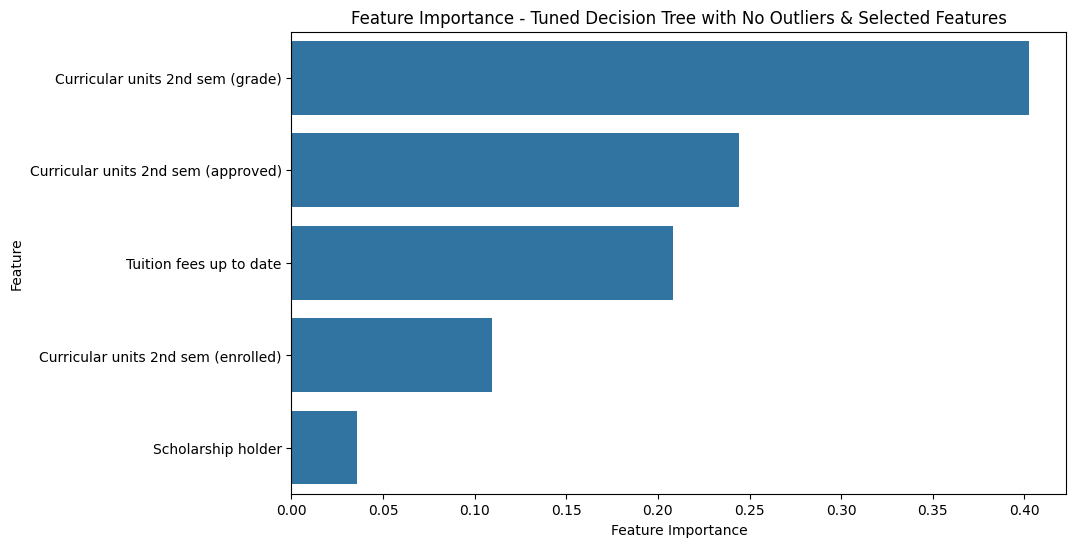

In [22]:
plot_feature_importance(dt_tuned_a_o_a_f, X_train_a_o_a_f.columns, "Feature Importance - Tuned Decision Tree with All Outliers & All Features")
plot_feature_importance(dt_tuned_a_o_s_f, X_train_a_o_s_f.columns, "Feature Importance - Tuned Decision Tree with All Outliers & Selected Features")
plot_feature_importance(dt_tuned_n_o_a_f, X_train_n_o_a_f.columns, "Feature Importance - Tuned Decision Tree with No Outliers & All Features")
plot_feature_importance(dt_tuned_n_o_s_f, X_train_n_o_s_f.columns, "Feature Importance - Tuned Decision Tree with No Outliers & Selected Features")

# **Decision Tree Model Evaluation Report (Synced to Latest Rerun)**
**Project:** Classification with Decision Tree  
**Tuning Method:** Coarse-to-Fine Search (RandomizedSearchCV -> GridSearchCV)  
**Validation:** Test split + 5-Fold CV (cell currently set on tuned NO+SF)

---

## 1. Tuned Model Results (Latest Rerun)

| Scenario | Accuracy | ROC-AUC |
|---|---:|---:|
| **All Outliers + Selected Features** | **0.7367** | **0.8488** |
| No Outliers + Selected Features | 0.7070 | 0.8163 |
| All Outliers + All Features | 0.7175 | 0.8072 |
| No Outliers + All Features | 0.7047 | 0.8033 |

### Cross Validation Snapshot
- CV cell result (Tuned No Outliers + Selected Features):
  - CV Mean (5-Fold): **0.7388**
  - CV Std (5-Fold): **0.0135**

---

## 2. Key Findings
- Berdasarkan hasil rerun, konfigurasi terbaik Decision Tree adalah **All Outliers + Selected Features**.
- Pada model Decision Tree ini, selected-features memberikan hasil lebih baik dibanding all-features.
- Kinerja kelas `Enrolled` masih menjadi area utama yang perlu ditingkatkan.

---

## 3. Final Recommendation
Gunakan **Tuned Decision Tree (All Outliers + Selected Features)** sebagai baseline/interpretable model dari notebook Decision Tree ini.

# **Saving Final Model**

In [ ]:
# MODEL_DIR = "../models/decision_tree_classifier_model"
# os.makedirs(MODEL_DIR, exist_ok=True)

# # Generate timestamp
# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# # Save the best model (Tuned Decision Tree - No Outliers + Selected Features)
# best_dt_model = dt_tuned_n_o_s_f
# model_filename = f"best_dt_classifier_model_{timestamp}.pkl"
# model_path = os.path.join(MODEL_DIR, model_filename)
# joblib.dump(best_dt_model, model_path)

# model_params = dt_tuned_n_o_s_f.get_params()

# feature_names       = X_train_n_o_s_f.columns.tolist()
# feature_importances = dt_tuned_n_o_s_f.feature_importances_

# feature_importance_dict = [
#     {
#         'feature'    : name,
#         'importance' : round(float(score), 6),
#         'percentage' : f"{round(float(score) * 100, 2)}%"
#     }
#     for name, score in sorted(
#         zip(feature_names, feature_importances),
#         key=lambda x: x[1],
#         reverse=True
#     )
# ]

# # Create metadata for the saved model
# model_metadata = {
#     'model_name'  : 'Tuned Decision Tree Classifier with No Outliers and Selected Features',
#     'description' : 'This model is a Decision Tree Classifier that has been tuned using GridSearchCV with a coarse-to-fine search strategy. It was trained on the dataset that excludes outliers and uses selected features only.',
#     'training_data': {
#         'dataset'          : 'data_cleaned_selected_with_no_outliers.csv',
#         'features'         : X_train_n_o_s_f.columns.tolist(),
#         'target'           : 'Target',
#         'train_test_split' : '80% train, 20% test',
#         'random_state'     : 42
#     },
#     'hyperparameters': {
#         'criterion'         : model_params['criterion'],
#         'max_depth'         : model_params['max_depth'],
#         'max_features'      : model_params['max_features'],
#         'min_samples_leaf'  : model_params['min_samples_leaf'],
#         'min_samples_split' : model_params['min_samples_split'],
#         'splitter'          : model_params['splitter'],
#         'class_weight'      : model_params['class_weight']
#     },
#     'performance': {
#         'accuracy'               : accuracy_score(y_test_n_o_s_f, dt_tuned_n_o_s_f_pred),
#         'roc_auc'                : roc_auc_score(y_test_n_o_s_f, dt_tuned_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'),
#         'classification_report'  : classification_report(y_test_n_o_s_f, dt_tuned_n_o_s_f_pred, output_dict=True)
#     },
#     'feature_importance' : feature_importance_dict,
#     'timestamp'          : timestamp,
#     'model_file'         : model_filename
# }

# # Save metadata
# metadata_filename = model_filename.replace('.pkl', '_metadata.json')
# metadata_path     = os.path.join(MODEL_DIR, metadata_filename)

# with open(metadata_path, 'w') as f:
#     json.dump(model_metadata, f, indent=4)